# Largest Time Gap across all Datasets

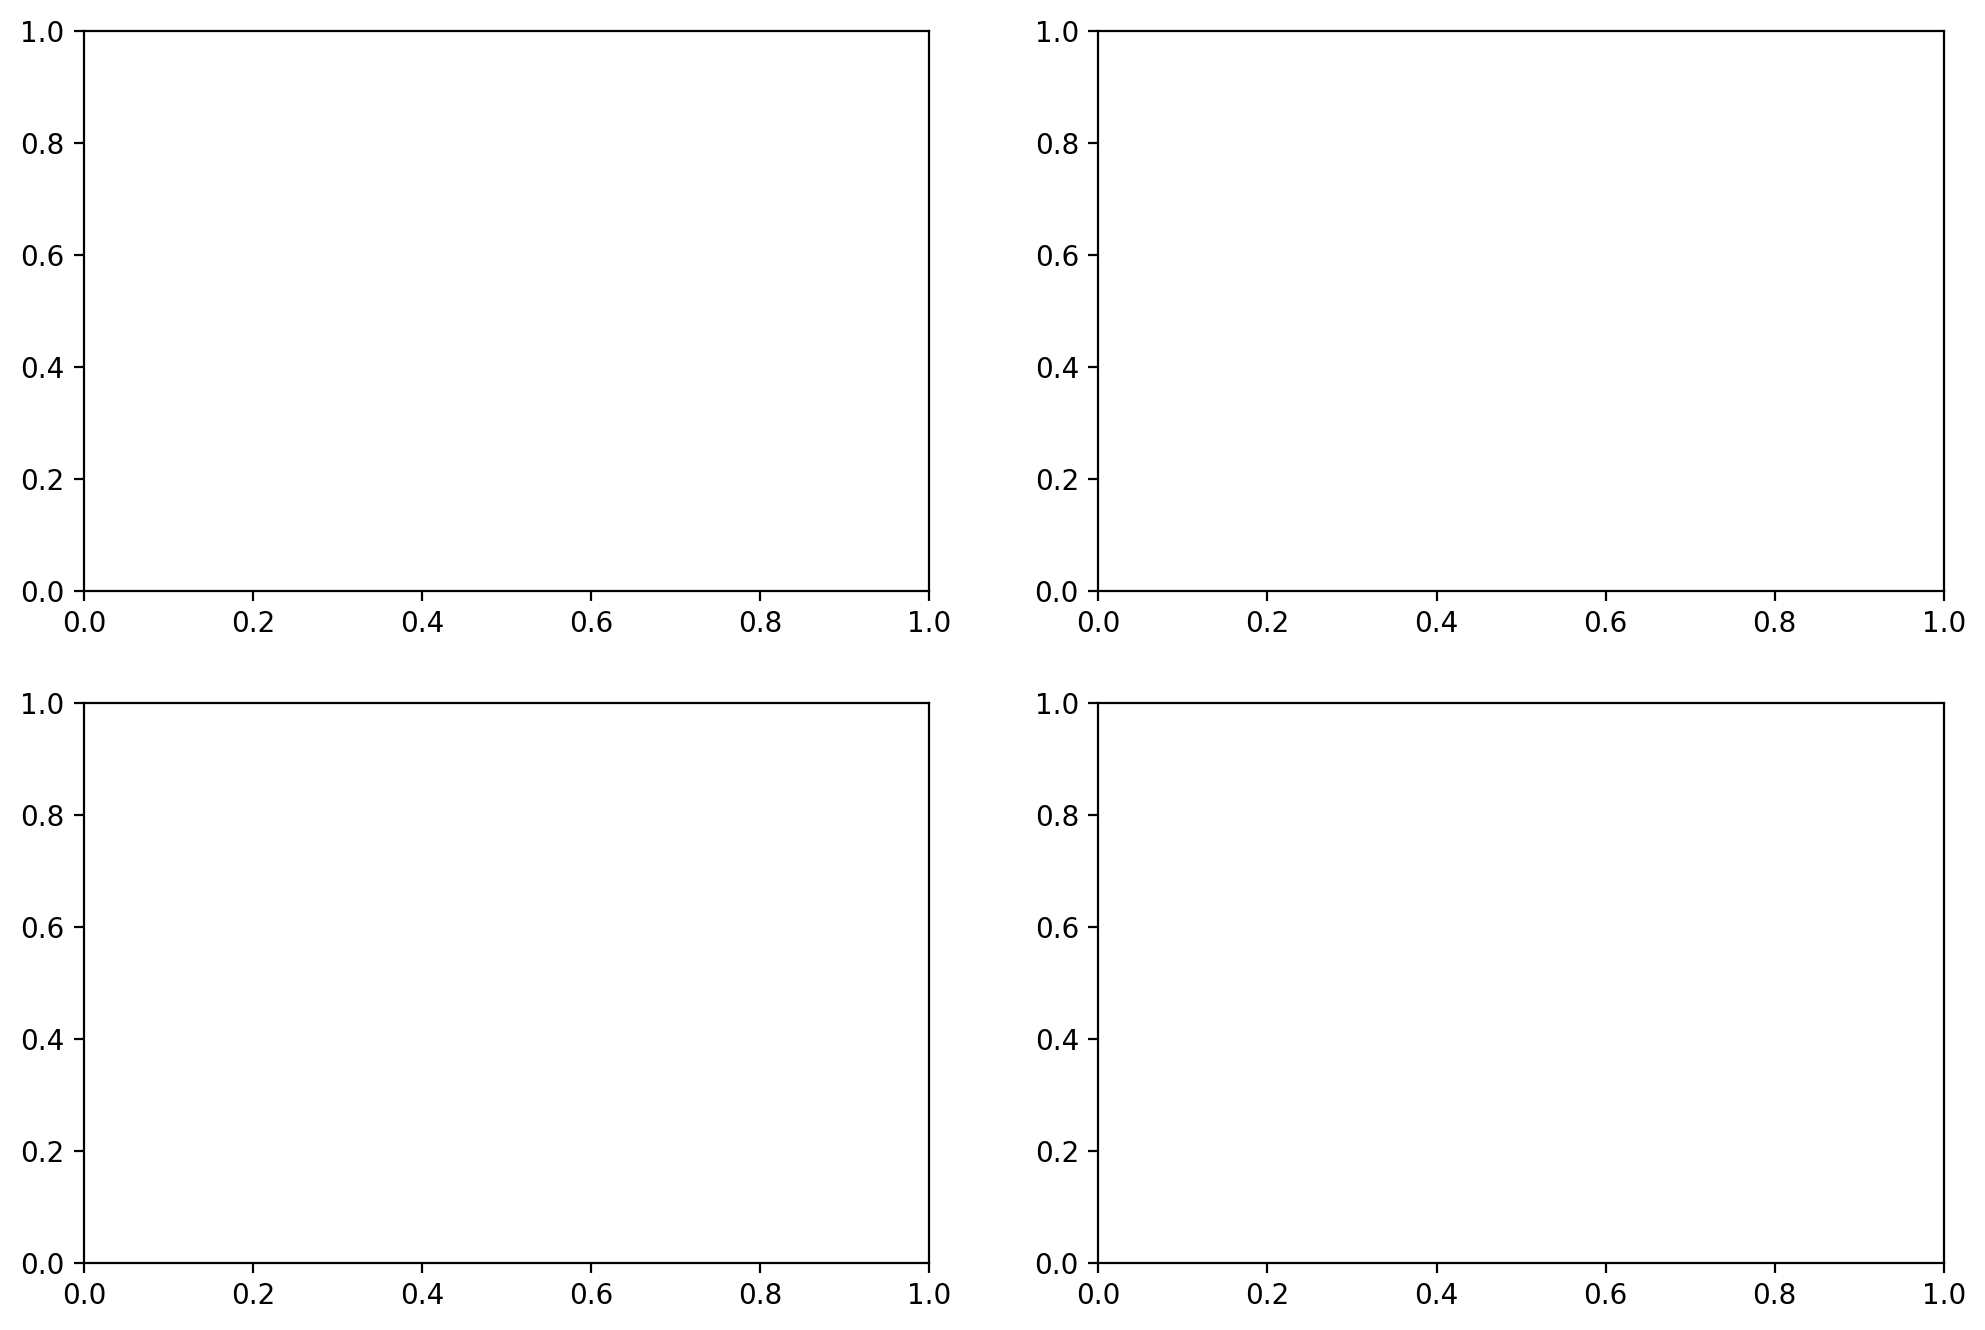

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np
import pandas as pd

fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8), dpi=200)

axes2_flat = axes2.flat

df_geolife = pd.read_csv(f'./data/Geolife/20260726_geolife_database_metrics.csv')

df_rmove = pd.read_csv(f'./data/rMove/20260726_rmove_database_metrics.csv')

# df_spectus = pd.read_csv(f'./data/Spectus/Lyra_Processed/20260726_spectus_database_metrics.csv')
df_spectus = pd.read_csv(f'./data/Spectus/20260726_TEST_30min_stop_minimum_spectus_database_metrics.csv')


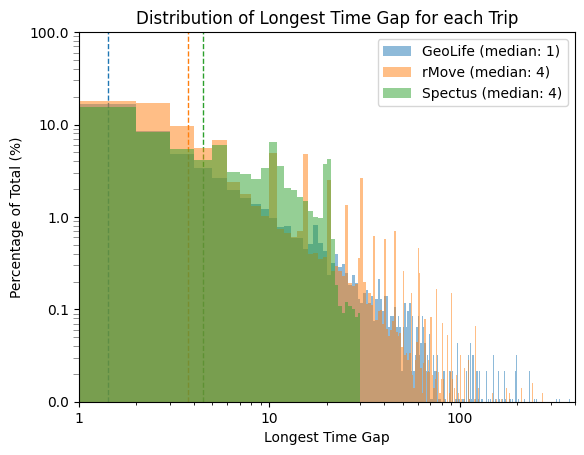

In [3]:
# ax2 = axes2_flat[0]
fig2, ax2 = plt.subplots()

filtered_geolife = df_geolife
filtered_rmove = df_rmove
filtered_spectus = df_spectus

weights_geolife = np.ones_like(filtered_geolife['longest_time_gap_minutes']) / len(filtered_geolife['longest_time_gap_minutes']) * 100
weights_rmove = np.ones_like(filtered_rmove['longest_time_gap_minutes']) / len(filtered_rmove['longest_time_gap_minutes']) * 100
weights_spectus = np.ones_like(filtered_spectus['longest_time_gap_minutes']) / len(filtered_spectus['longest_time_gap_minutes']) * 100

median_geolife = filtered_geolife['longest_time_gap_minutes'].median()
median_rmove = filtered_rmove['longest_time_gap_minutes'].median()
median_spectus = filtered_spectus['longest_time_gap_minutes'].median()

ax2.axvline(median_geolife, color='C0', linestyle='--', linewidth=1, zorder=1)
ax2.axvline(median_rmove, color='C1', linestyle='--', linewidth=1, zorder=1)
ax2.axvline(median_spectus, color='C2', linestyle='--', linewidth=1, zorder=1)

ax2.hist(filtered_geolife['longest_time_gap_minutes'], bins=400, range=(0, 400), alpha=0.5, label=f'GeoLife (median: {median_geolife:.0f})', weights=weights_geolife, zorder=2)
ax2.hist(filtered_rmove['longest_time_gap_minutes'], bins=400, range=(0, 400), alpha=0.5, label=f'rMove (median: {median_rmove:.0f})', weights=weights_rmove, zorder=2)
ax2.hist(filtered_spectus['longest_time_gap_minutes'], bins=40, range=(0, 40), alpha=0.5, label=f'Spectus (median: {median_spectus:.0f})', weights=weights_spectus, zorder=2)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(1, 400)
ax2.set_ylim(0.01, 100)
ax2.tick_params(axis='y', which='minor', length=4, color='gray')
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.yaxis.set_major_formatter(ScalarFormatter())

ax2.set_xlabel('Longest Time Gap')
ax2.set_ylabel('Percentage of Total (%)')
ax2.set_title('Distribution of Longest Time Gap for each Trip')
ax2.legend()